Mustafa Sefa Soysal // 23050111037

# 1 – Data Creation
Downloads MS COCO 2017, generates synthetic shape dataset and saves it to Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install pycocotools

## Step 1: Download COCO Data to Google Drive

In [3]:
# Define the path to your COCO dataset folder in Google Drive
# This variable should be consistent with `drive_coco_path` in previous cells.
COCO_DRIVE_PATH = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'

print(f"Changing directory to: {COCO_DRIVE_PATH}")
%cd {COCO_DRIVE_PATH}

print("\n--- Downloading Annotations ---")
# Download annotations (one zip contains train/val/test annotations)
!wget -nc http://images.cocodataset.org/annotations/annotations_trainval2017.zip
# (We removed the unzip command here to prevent Google Drive from freezing)

print("\n--- Downloading Training Images ---")
# Download training images
!wget -nc http://images.cocodataset.org/zips/train2017.zip
# (We removed the unzip command here to prevent Google Drive from freezing)

print("\n--- Downloading Validation Images ---")
# Download validation images
!wget -nc http://images.cocodataset.org/zips/val2017.zip
# (We removed the unzip command here to prevent Google Drive from freezing)

print("\nReverting directory to /content")
%cd /content

print("\nCOCO dataset ZIP files successfully stored in your Google Drive.")
print("We skipped unzipping them here because Google Drive is too slow for 100k+ files.")
print("Move on to Step 4 to quickly extract them to Colab's local SSD!")

Changing directory to: /content/drive/MyDrive/Neural_Practice_Exam/COCO
/content/drive/MyDrive/Neural_Practice_Exam/COCO

--- Downloading Annotations ---
File ‘annotations_trainval2017.zip’ already there; not retrieving.


--- Downloading Training Images ---
File ‘train2017.zip’ already there; not retrieving.


--- Downloading Validation Images ---
File ‘val2017.zip’ already there; not retrieving.


Reverting directory to /content
/content

COCO dataset ZIP files successfully stored in your Google Drive.
We skipped unzipping them here because Google Drive is too slow for 100k+ files.
Move on to Step 4 to quickly extract them to Colab's local SSD!


## Step 2: Copy COCO to Fast Local Storage

In [4]:
import os
import shutil

# --- Configuration: UPDATE THESE PATHS ---
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'
local_coco_path = '/content/coco_dataset_local'

# Create the local directory if it doesn't exist
os.makedirs(local_coco_path, exist_ok=True)

print(f"Setting up COCO data in fast local Colab storage ('{local_coco_path}')...")

# --- 1. Copy Annotations ---
drive_annotations_src = os.path.join(drive_coco_path, 'annotations')
local_annotations_dst = os.path.join(local_coco_path, 'annotations')

if os.path.exists(drive_annotations_src) and not os.path.exists(local_annotations_dst):
    print(f"  Copying annotations...")
    try:
        shutil.copytree(drive_annotations_src, local_annotations_dst, dirs_exist_ok=True)
    except OSError as e:
        print(f"\n⚠️ GOOGLE DRIVE BAĞLANTISI KOPTU! (Transport endpoint error)\nLütfen üstteki drive.mount hücresini tekrar çalıştırın veya çalışma zamanını yeniden başlatın.\nHata detayı: {e}")
    print("  Annotations copied successfully.")
elif os.path.exists(local_annotations_dst):
    print("  Annotations already exist in local storage. Skipping copy.")

# --- 2. FAST IMAGE EXTRACTION: Unzip directly to local disk ---
# Instead of copying 100k loose files from Drive (which takes hours),
# we unzip the zip file stored in Drive directly to the fast local SSD.
local_img_dir = os.path.join(local_coco_path, 'images')
os.makedirs(local_img_dir, exist_ok=True)

train_zip = os.path.join(drive_coco_path, 'train2017.zip')
val_zip = os.path.join(drive_coco_path, 'val2017.zip')

print("\n--- Extracting Images to Local Disk ---")
if not os.path.exists(os.path.join(local_img_dir, 'train2017')):
    if os.path.exists(train_zip):
        print("  Unzipping train2017.zip directly to local storage (this is fast)...")
        !unzip -q "{train_zip}" -d "{local_img_dir}"
    else:
        print(f"  Warning: {train_zip} not found in Drive. Ensure it was downloaded in Step 3.")
else:
    print("  train2017 images already exist locally.")

if not os.path.exists(os.path.join(local_img_dir, 'val2017')):
    if os.path.exists(val_zip):
        print("  Unzipping val2017.zip directly to local storage...")
        !unzip -q "{val_zip}" -d "{local_img_dir}"
    else:
        print(f"  Warning: {val_zip} not found in Drive. Ensure it was downloaded in Step 3.")
else:
    print("  val2017 images already exist locally.")

print("\nCOCO data setup for local access complete! Your GPU will no longer be bottlenecked by Drive I/O.")

Setting up COCO data in fast local Colab storage ('/content/coco_dataset_local')...
  Annotations already exist in local storage. Skipping copy.

--- Extracting Images to Local Disk ---
  train2017 images already exist locally.
  val2017 images already exist locally.

COCO data setup for local access complete! Your GPU will no longer be bottlenecked by Drive I/O.


## Step 3: Load COCO Annotations

In [5]:
import os
from pycocotools.coco import COCO

# --- Robust Path Resolution ---
local_coco_path = '/content/coco_dataset_local'
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'

# Handle nested annotations dynamically (Local first, then Drive)
base_ann_local = os.path.join(local_coco_path, 'annotations')
base_ann_drive = os.path.join(drive_coco_path, 'annotations')

if os.path.exists(os.path.join(base_ann_local, 'annotations', 'instances_train2017.json')):
    annotations_dir = os.path.join(base_ann_local, 'annotations')
elif os.path.exists(os.path.join(base_ann_local, 'instances_train2017.json')):
    annotations_dir = base_ann_local
elif os.path.exists(os.path.join(base_ann_drive, 'annotations', 'instances_train2017.json')):
    annotations_dir = os.path.join(base_ann_drive, 'annotations')
else:
    annotations_dir = base_ann_drive

annotation_filename = 'instances_train2017.json'
annotation_file = os.path.join(annotations_dir, annotation_filename)

print(f"Using annotation directory: {annotations_dir}")

if not os.path.exists(annotation_file):
    print(f"Error: Annotation file not found at {annotation_file}")
else:
    print(f"Successfully found annotation file: {annotation_file}")
    coco = COCO(annotation_file)
    print("\n--- COCO Dataset Information ---")
    cats = coco.loadCats(coco.getCatIds())
    print('COCO categories: %s' % ', '.join([cat['name'] for cat in cats]))
    print(f"Total images: {len(coco.getImgIds())}")

Using annotation directory: /content/coco_dataset_local/annotations/annotations
Successfully found annotation file: /content/coco_dataset_local/annotations/annotations/instances_train2017.json
loading annotations into memory...
Done (t=12.33s)
creating index...
index created!

--- COCO Dataset Information ---
COCO categories: person, bicycle, car, motorcycle, airplane, bus, train, truck, boat, traffic light, fire hydrant, stop sign, parking meter, bench, bird, cat, dog, horse, sheep, cow, elephant, bear, zebra, giraffe, backpack, umbrella, handbag, tie, suitcase, frisbee, skis, snowboard, sports ball, kite, baseball bat, baseball glove, skateboard, surfboard, tennis racket, bottle, wine glass, cup, fork, knife, spoon, bowl, banana, apple, sandwich, orange, broccoli, carrot, hot dog, pizza, donut, cake, chair, couch, potted plant, bed, dining table, toilet, tv, laptop, mouse, remote, keyboard, cell phone, microwave, oven, toaster, sink, refrigerator, book, clock, vase, scissors, teddy b

## Step 4: Load COCO Images via torchvision

In [6]:
import torch
import torchvision
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor
import os

# Path to the local COCO dataset root
local_coco_path = '/content/coco_dataset_local'

# Because you commented out the image copy step earlier (to save time),
# the images are likely still in your Google Drive.
# We will dynamically check local first, then fallback to Drive.
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'

local_img_dir = os.path.join(local_coco_path, 'images', 'train2017')
drive_img_dir = os.path.join(drive_coco_path, 'images', 'train2017')

if os.path.exists(local_img_dir):
    image_root_dir = local_img_dir
    print(f"Using local image directory: {image_root_dir}")
else:
    image_root_dir = drive_img_dir
    print(f"Using Google Drive image directory: {image_root_dir}")

# Handle the nested annotations directory again
base_annotations_dir = os.path.join(local_coco_path, 'annotations')
if os.path.exists(os.path.join(base_annotations_dir, 'annotations', 'instances_train2017.json')):
    annotations_dir = os.path.join(base_annotations_dir, 'annotations')
else:
    annotations_dir = base_annotations_dir

annotation_file_path = os.path.join(annotations_dir, 'instances_train2017.json')

# --- Verify paths before creating dataset ---
if not os.path.exists(image_root_dir):
    print(f"Error: Image root directory not found: {image_root_dir}")
elif not os.path.exists(annotation_file_path):
    print(f"Error: Annotation file not found: {annotation_file_path}")
else:
    print(f"Image root directory found: {image_root_dir}")
    print(f"Annotation file found: {annotation_file_path}")

    # Create the CocoDetection dataset
    dataset = CocoDetection(
        root=image_root_dir,
        annFile=annotation_file_path
    )

    print(f"\nSuccessfully loaded COCO dataset with {len(dataset)} items.")

    # Example: Access an item
    if len(dataset) > 0:
        img, target = dataset[0]
        print(f"\nFirst image type: {type(img)}")
        print(f"First image size: {img.size}")
    else:
        print("Dataset is empty.")

Using local image directory: /content/coco_dataset_local/images/train2017
Image root directory found: /content/coco_dataset_local/images/train2017
Annotation file found: /content/coco_dataset_local/annotations/annotations/instances_train2017.json
loading annotations into memory...
Done (t=11.92s)
creating index...
index created!

Successfully loaded COCO dataset with 118287 items.

First image type: <class 'PIL.Image.Image'>
First image size: (640, 480)


## Step 5: Fixed Train / Val / Test Split + Seed Function

In [7]:
import os
import hashlib
import copy
import torchvision
from torchvision.datasets import CocoDetection

# --- 1. Deterministic Seed Generation ---
GLOBAL_SEED = 2025

def make_seed(split_name, image_id, global_seed=GLOBAL_SEED):
    key = f"{split_name}_{image_id}_{global_seed}".encode("utf-8")
    return int(hashlib.sha256(key).hexdigest()[:8], 16)

# --- 2. Dynamic Paths (Local first, then Drive) ---
local_coco_path = '/content/coco_dataset_local'
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'

def get_img_dir(split):
    local_dir = os.path.join(local_coco_path, 'images', split)
    drive_dir = os.path.join(drive_coco_path, 'images', split)
    return local_dir if os.path.exists(local_dir) else drive_dir

train_img_dir = get_img_dir('train2017')
val_img_dir = get_img_dir('val2017')

base_ann_local = os.path.join(local_coco_path, 'annotations')
base_ann_drive = os.path.join(drive_coco_path, 'annotations')

if os.path.exists(os.path.join(base_ann_local, 'annotations', 'instances_train2017.json')):
    ann_dir = os.path.join(base_ann_local, 'annotations')
elif os.path.exists(os.path.join(base_ann_local, 'instances_train2017.json')):
    ann_dir = base_ann_local
elif os.path.exists(os.path.join(base_ann_drive, 'annotations', 'instances_train2017.json')):
    ann_dir = os.path.join(base_ann_drive, 'annotations')
else:
    ann_dir = base_ann_drive

train_ann_file = os.path.join(ann_dir, 'instances_train2017.json')
val_ann_file = os.path.join(ann_dir, 'instances_val2017.json')

print(f"Using Train Images: {train_img_dir}")
print(f"Using Val Images: {val_img_dir}")
print(f"Using Annotations: {ann_dir}\n")

print("Loading annotations (this may take a moment)...")
try:
    # Initialize full datasets
    train_dataset_full = CocoDetection(root=train_img_dir, annFile=train_ann_file)
    val_dataset_full = CocoDetection(root=val_img_dir, annFile=val_ann_file)

    # --- 3. Sort COCO image IDs in increasing order ---
    train_dataset_full.ids = sorted(train_dataset_full.ids)
    val_dataset_full.ids = sorted(val_dataset_full.ids)

    # --- 4, 5, 6. Create the subsets by slicing the IDs ---
    train_dataset = copy.copy(train_dataset_full)
    train_dataset.ids = train_dataset_full.ids[:5000]

    val_dataset = copy.copy(val_dataset_full)
    val_dataset.ids = val_dataset_full.ids[:1000]

    test_dataset = copy.copy(val_dataset_full)
    test_dataset.ids = val_dataset_full.ids[1000:2000]

    print("\n--- Dataset Splits Created Successfully ---")
    print(f"Training subset size:   {len(train_dataset)} images")
    print(f"Validation subset size: {len(val_dataset)} images")
    print(f"Test subset size:       {len(test_dataset)} images")

except Exception as e:
    print(f"\nAn error occurred: {e}")
    print("Please double check the paths to your images and annotations. If you get an OSError, your Google Drive might be timing out.")

Using Train Images: /content/coco_dataset_local/images/train2017
Using Val Images: /content/coco_dataset_local/images/val2017
Using Annotations: /content/coco_dataset_local/annotations/annotations

Loading annotations (this may take a moment)...
loading annotations into memory...
Done (t=11.87s)
creating index...
index created!
loading annotations into memory...
Done (t=0.53s)
creating index...
index created!

--- Dataset Splits Created Successfully ---
Training subset size:   5000 images
Validation subset size: 1000 images
Test subset size:       1000 images


## Step 6: Synthetic Shape Generator

In [8]:
import random
import math
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import torch
import matplotlib.pyplot as plt

def add_synthetic_shapes(base_image, seed=None, prob_positive=0.7):
    """
    Adds synthetic shapes to a PIL image for Semantic Segmentation.
    Returns the modified image and a target dict containing a binary mask.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    is_positive = random.random() < prob_positive
    num_shapes = random.randint(1, 3) if is_positive else 0

    # Convert to RGBA for transparent drawing
    img = base_image.convert("RGBA")
    overlay = Image.new("RGBA", img.size, (255, 255, 255, 0))
    mask_np = np.zeros((img.size[1], img.size[0]), dtype=np.uint8)

    w, h = img.size

    for _ in range(num_shapes):
        shape_type = random.choice(['rectangle', 'ellipse', 'triangle', 'star', 'line'])

        # Difficulty #1: Random opacity & partial transparency
        alpha = random.randint(80, 200)
        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255), alpha)

        # Random Size & Location
        sw, sh = random.randint(w//10, w//3), random.randint(h//10, h//3)
        sx = random.randint(0, max(1, w - sw))
        sy = random.randint(0, max(1, h - sh))
        bbox = [sx, sy, sx+sw, sy+sh]

        # Create temporary canvases for rotation
        temp_img = Image.new("RGBA", img.size, (255, 255, 255, 0))
        temp_draw = ImageDraw.Draw(temp_img)
        temp_mask = Image.new("L", img.size, 0)
        temp_mask_draw = ImageDraw.Draw(temp_mask)

        if shape_type == 'rectangle':
            temp_draw.rectangle(bbox, fill=color)
            temp_mask_draw.rectangle(bbox, fill=1)
        elif shape_type == 'ellipse':
            temp_draw.ellipse(bbox, fill=color)
            temp_mask_draw.ellipse(bbox, fill=1)
        elif shape_type == 'triangle':
            p1 = (sx + sw//2, sy)
            p2 = (sx, sy + sh)
            p3 = (sx + sw, sy + sh)
            temp_draw.polygon([p1, p2, p3], fill=color)
            temp_mask_draw.polygon([p1, p2, p3], fill=1)
        elif shape_type == 'star':
            # Draw a 5-pointed star
            cx, cy = sx + sw//2, sy + sh//2
            r_out = min(sw, sh) // 2
            r_in = r_out // 2
            pts = []
            for i in range(10):
                angle = i * math.pi / 5 - math.pi / 2
                r = r_out if i % 2 == 0 else r_in
                pts.append((cx + r * math.cos(angle), cy + r * math.sin(angle)))
            temp_draw.polygon(pts, fill=color)
            temp_mask_draw.polygon(pts, fill=1)
        elif shape_type == 'line':
            # Draw a thick line
            line_width = random.randint(sh//4, sh//2)
            temp_draw.line([(sx, sy), (sx+sw, sy+sh)], fill=color, width=line_width)
            temp_mask_draw.line([(sx, sy), (sx+sw, sy+sh)], fill=1, width=line_width)

        # Required Variation: Rotation
        angle = random.randint(0, 359)
        center = (sx + sw//2, sy + sh//2)
        temp_img = temp_img.rotate(angle, center=center, fillcolor=(0,0,0,0), expand=False, resample=Image.BICUBIC)
        temp_mask = temp_mask.rotate(angle, center=center, fillcolor=0, expand=False, resample=Image.NEAREST)

        # Difficulty #2: Overlapping shapes (Composite the temp layer)
        overlay = Image.alpha_composite(overlay, temp_img)
        mask_np = np.maximum(mask_np, np.array(temp_mask))

    # Composite final overlay onto base image
    img = Image.alpha_composite(img, overlay)

    # Difficulty #3: Random Blur
    if random.random() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))

    img = img.convert("RGB")

    # Difficulty #4: Additive Noise
    if random.random() < 0.5:
        img_np_array = np.array(img).astype(np.float32)
        noise = np.random.normal(0, 15, img_np_array.shape) # Gaussian noise
        img_np_array = np.clip(img_np_array + noise, 0, 255).astype(np.uint8)
        img = Image.fromarray(img_np_array)

    target = {
        'mask': torch.tensor(mask_np, dtype=torch.long),
        'is_positive': torch.tensor([1 if is_positive else 0], dtype=torch.int64),
        'num_shapes': torch.tensor([num_shapes], dtype=torch.int64)
    }

    return img, target

print("Synthetic shape generator UPDATED with Stars, Lines, and Rotation!")

Synthetic shape generator UPDATED with Stars, Lines, and Rotation!


## Step 7: PyTorch Dataset Wrapper

In [9]:
import torch
from torch.utils.data import Dataset
import torchvision.tv_tensors as tv_tensors

class SyntheticShapeDataset(Dataset):
    def __init__(self, coco_subset, split_name, transform=None):
        """
        Args:
            coco_subset: The subset of CocoDetection (train, val, or test).
            split_name: 'train', 'val', or 'test'. Used for seed generation.
            transform: Optional v2 transform to be applied symmetrically to image and mask.
        """
        self.coco_subset = coco_subset
        self.split_name = split_name
        self.transform = transform

    def __len__(self):
        return len(self.coco_subset)

    def __getitem__(self, idx):
        # Get original image and image ID from the underlying COCO subset
        img_id = self.coco_subset.ids[idx]
        orig_img, _ = self.coco_subset[idx]

        # 1. Use deterministic seed ONLY for validation and test splits
        seed = None
        if self.split_name in ['val', 'test']:
            seed = make_seed(self.split_name, img_id)

        # 2. Apply the synthetic shape generator
        syn_img, target = add_synthetic_shapes(orig_img, seed=seed)

        # 3. Cleanly add image_id to the target dictionary (Done ONLY here)
        target['image_id'] = torch.tensor([img_id], dtype=torch.int64)

        # 4. Apply v2 Transforms symmetrically (if provided)
        if self.transform:
            # Wrap mask and image in tv_tensors for v2 transformations
            img_tensor = tv_tensors.Image(syn_img)
            mask_tensor = tv_tensors.Mask(target['mask'].unsqueeze(0))

            # Apply spatial transforms
            transformed_img, transformed_mask = self.transform(img_tensor, mask_tensor)

            # Reassign transformed outputs
            syn_img = transformed_img
            target['mask'] = transformed_mask.squeeze(0).long() # Remove channel dim for loss fn

        return syn_img, target

print("Unified Custom Dataset class defined for Option B!")

Unified Custom Dataset class defined for Option B!


## Step 8: Visualize 12 Generated Samples

Generating 12 visual examples...


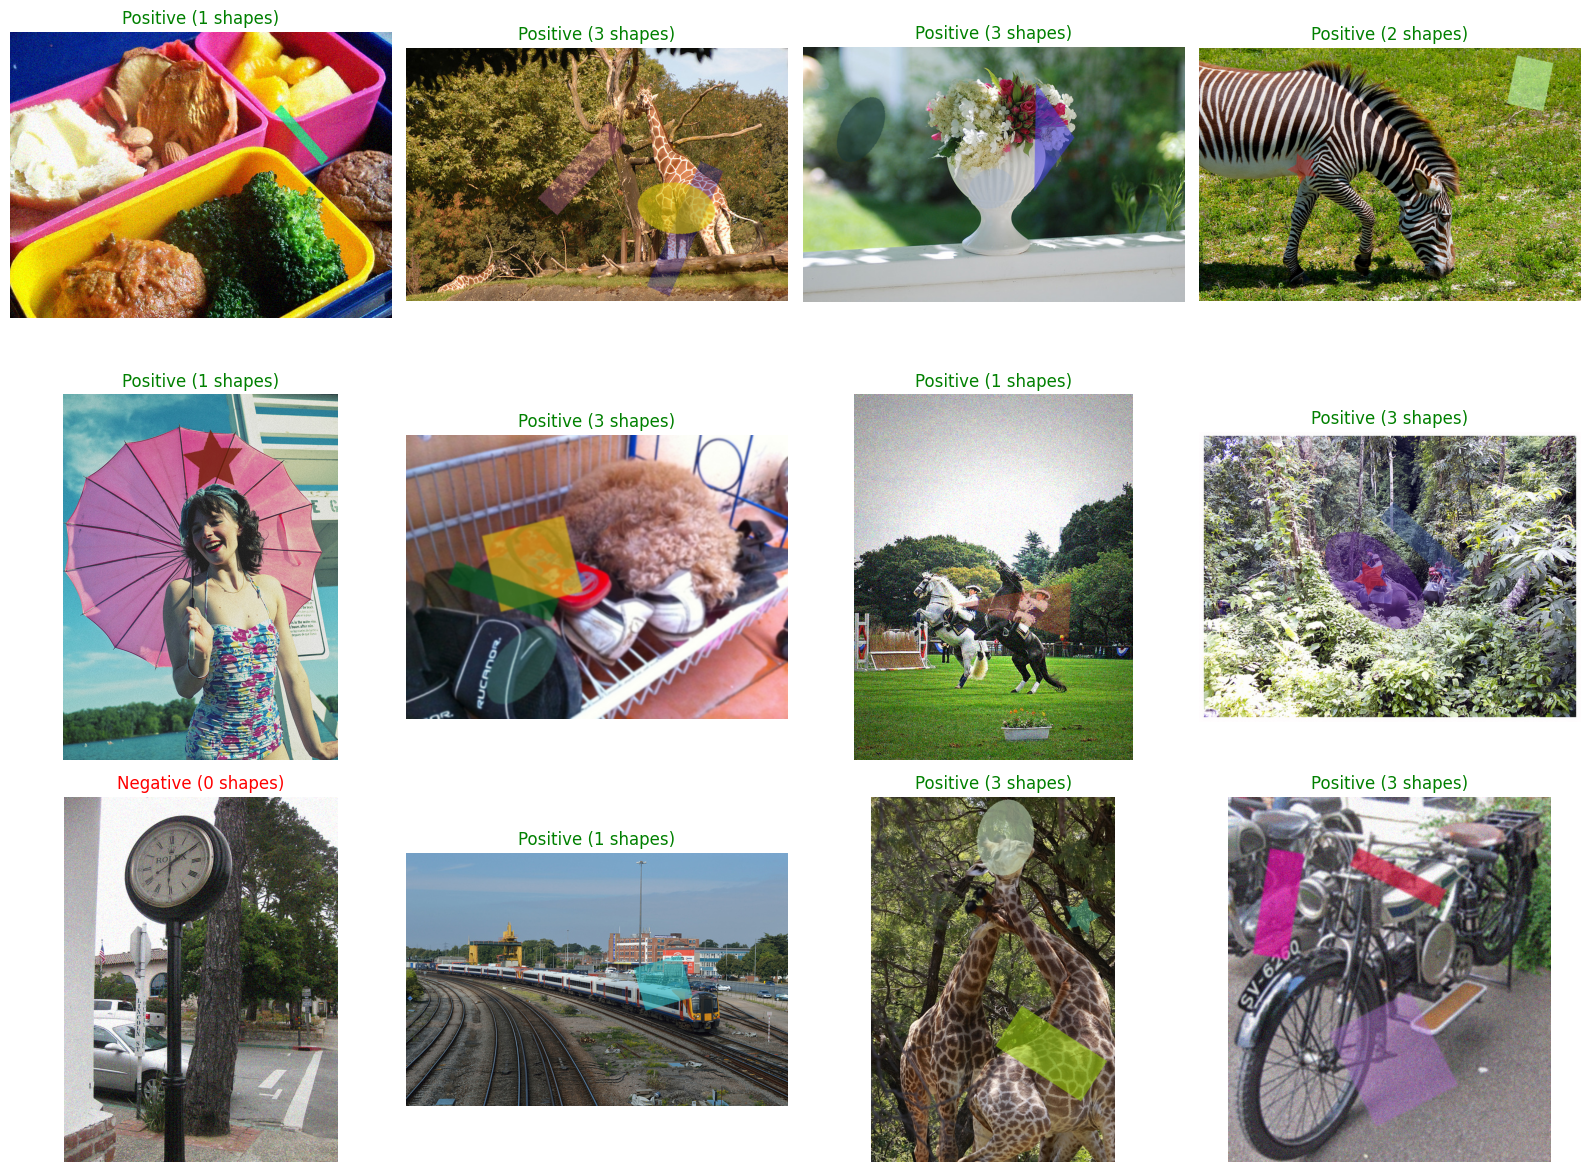

In [10]:
def visualize_synthetic_samples(dataset, num_samples=12):
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for i in range(num_samples):
        # Get original image
        img_id = dataset.ids[i]
        # We use standard load so we don't mess with transforms yet
        orig_img, _ = dataset[i]

        # Generate reproducible seed for visualization consistency
        seed = make_seed("train_vis", img_id)

        # Apply synthetic shapes
        syn_img, target = add_synthetic_shapes(orig_img, seed=seed)

        is_pos = target['is_positive'].item() == 1
        n_shapes = target['num_shapes'].item()

        axes[i].imshow(syn_img)
        title = f"Positive ({n_shapes} shapes)" if is_pos else "Negative (0 shapes)"
        axes[i].set_title(title, color='green' if is_pos else 'red')
        axes[i].axis('off')

    plt.tight_layout()
    import os
    os.makedirs('results/figures', exist_ok=True)
    plt.savefig('results/figures/generated_samples_grid.png', bbox_inches='tight')
    plt.show()

# Run visualization if the train_dataset is available
if 'train_dataset' in locals():
    print("Generating 12 visual examples...")
    visualize_synthetic_samples(train_dataset, num_samples=12)
else:
    print("Please run the dataset split cell first.")

In [11]:
train_coco_subset = train_dataset
val_coco_subset   = val_dataset
test_coco_subset  = test_dataset


## Step 9: Save Generated Dataset to Disk → ZIP → Google Drive

In [12]:
import os, shutil
from PIL import Image

save_dir = 'synthetic_dataset'
for split in ['train', 'test']:
    os.makedirs(f'{save_dir}/{split}/images', exist_ok=True)
    os.makedirs(f'{save_dir}/{split}/masks',  exist_ok=True)

train_save_ds = SyntheticShapeDataset(train_coco_subset, 'train')
test_save_ds  = SyntheticShapeDataset(test_coco_subset,  'test')

def save_split(dataset, split_name):
    print(f'Saving {split_name} ({len(dataset)} samples)...')
    for idx in range(len(dataset)):
        img, target = dataset[idx]
        mask_t = target['mask']

        # img might be PIL Image or Tensor — handle both
        if not isinstance(img, Image.Image):
            import torchvision.transforms.functional as TF
            img = TF.to_pil_image(img)

        # mask is always a tensor
        import torchvision.transforms.functional as TF2
        mask_pil = TF2.to_pil_image(mask_t.float())

        img.save(f'{save_dir}/{split_name}/images/{idx}.jpg')
        mask_pil.save(f'{save_dir}/{split_name}/masks/{idx}.png')

        if idx % 500 == 0:
            print(f'  {idx}/{len(dataset)}...')
    print(f'{split_name} saved!')

save_split(train_save_ds, 'train')
save_split(test_save_ds,  'test')

print('Zipping...')
shutil.make_archive('synthetic_dataset', 'zip', '.', 'synthetic_dataset')
print('Done! synthetic_dataset.zip ready.')


Saving train (5000 samples)...
  0/5000...
  500/5000...
  1000/5000...
  1500/5000...
  2000/5000...
  2500/5000...
  3000/5000...
  3500/5000...
  4000/5000...
  4500/5000...
train saved!
Saving test (1000 samples)...
  0/1000...
  500/1000...
test saved!
Zipping...
Done! synthetic_dataset.zip ready.


In [13]:
# Upload synthetic_dataset.zip to Google Drive
import shutil, os
drive_folder = '/content/drive/MyDrive/Neural_Practice_Exam'
os.makedirs(drive_folder, exist_ok=True)
shutil.copy('synthetic_dataset.zip', os.path.join(drive_folder, 'synthetic_dataset.zip'))
print('Uploaded synthetic_dataset.zip to Google Drive!')


Uploaded synthetic_dataset.zip to Google Drive!
